# Notebook 04 - Random Forest

This notebook trains and evaluates a Random Forest classifier for IoT intrusion detection. Random Forest is a strong tree-based baseline and handles raw feature scales well.

## 1. Imports

Load the libraries for data loading, model training, evaluation, plotting, and saving artifacts.

The code below imports Random Forest, grid search tools, metrics, plotting libraries, and saving utilities.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    log_loss, recall_score, precision_score, accuracy_score
)
from sklearn.model_selection import GridSearchCV, PredefinedSplit

## 2. Load Preprocessed Data

Load the feature variants and labels from Notebook 2. We also keep feature names for the feature-importance plot.

The code below loads all saved feature variants, labels, and feature names.

In [2]:
DATA_DIR = Path('../data/processed')
print('Using processed folder:', DATA_DIR.resolve())


def load_csv(name, base_dir=DATA_DIR):
    path = base_dir / name
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')
    return pd.read_csv(path)


# --- Feature splits ---
X_train_raw        = load_csv('X_train_raw.csv')
X_val_raw          = load_csv('X_val_raw.csv')
X_test_raw         = load_csv('X_test_raw.csv')

# Capture feature names before converting to numpy (used in feature importance)
feature_names = list(X_train_raw.columns)

X_train_out        = load_csv('X_train_out.csv')
X_val_out          = load_csv('X_val_out.csv')
X_test_out         = load_csv('X_test_out.csv')

X_train_scaled     = load_csv('X_train_scaled.csv')
X_val_scaled       = load_csv('X_val_scaled.csv')
X_test_scaled      = load_csv('X_test_scaled.csv')

X_train_out_scaled = load_csv('X_train_out_scaled.csv')
X_val_out_scaled   = load_csv('X_val_out_scaled.csv')
X_test_out_scaled  = load_csv('X_test_out_scaled.csv')

# --- Label splits ---
y_train_df = load_csv('y_train_encoded.csv')
y_val_df   = load_csv('y_val_encoded.csv')
y_test_df  = load_csv('y_test_encoded.csv')

for name, df in [('y_train', y_train_df), ('y_val', y_val_df), ('y_test', y_test_df)]:
    if df.shape[1] != 1:
        raise ValueError(f'{name}_encoded.csv must contain exactly one column.')

y_train = y_train_df.iloc[:, 0].to_numpy()
y_val   = y_val_df.iloc[:, 0].to_numpy()
y_test  = y_test_df.iloc[:, 0].to_numpy()

# --- Convert features to numpy ---
X_train_raw        = X_train_raw.to_numpy()
X_val_raw          = X_val_raw.to_numpy()
X_test_raw         = X_test_raw.to_numpy()

X_train_out        = X_train_out.to_numpy()
X_val_out          = X_val_out.to_numpy()
X_test_out         = X_test_out.to_numpy()

X_train_scaled     = X_train_scaled.to_numpy()
X_val_scaled       = X_val_scaled.to_numpy()
X_test_scaled      = X_test_scaled.to_numpy()

X_train_out_scaled = X_train_out_scaled.to_numpy()
X_val_out_scaled   = X_val_out_scaled.to_numpy()
X_test_out_scaled  = X_test_out_scaled.to_numpy()

# --- Organize into a dictionary ---
splits = {
    'raw':        {'X_train': X_train_raw,        'X_val': X_val_raw,        'X_test': X_test_raw},
    'out':        {'X_train': X_train_out,        'X_val': X_val_out,        'X_test': X_test_out},
    'scaled':     {'X_train': X_train_scaled,     'X_val': X_val_scaled,     'X_test': X_test_scaled},
    'out_scaled': {'X_train': X_train_out_scaled, 'X_val': X_val_out_scaled, 'X_test': X_test_out_scaled},
}

print('Data loaded successfully.')
print(f'Train: {y_train.shape[0]} samples | Val: {y_val.shape[0]} | Test: {y_test.shape[0]}')
print(f'Features: {len(feature_names)} | Classes: {len(np.unique(y_train))}')

Using processed folder: C:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\processed
Data loaded successfully.
Train: 901868 samples | Val: 193258 | Test: 193258
Features: 39 | Classes: 34


## 3. Select Feature Version

Random Forest does not need scaled inputs because tree splits depend on ordering, not feature magnitude. Raw or outlier-clipped variants are the main ones to test.

The code below selects which feature variant the Random Forest will train on.

In [3]:
# Options: 'raw' | 'out' | 'scaled' | 'out_scaled'
# For RF: 'out' is the right choice — scaling has no effect on tree splits
FEATURE_VERSION = 'scaled'

X_train = splits[FEATURE_VERSION]['X_train']
X_val   = splits[FEATURE_VERSION]['X_val']
X_test  = splits[FEATURE_VERSION]['X_test']
# y arrays are identical across all variants — no change needed

print(f'Feature version selected: {FEATURE_VERSION}')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_val: {y_val.shape} | y_test: {y_test.shape}')
print('\nClass distribution in y_train:')
print(pd.Series(y_train).value_counts().sort_index())

Feature version selected: scaled
X_train: (901868, 39) | X_val: (193258, 39) | X_test: (193258, 39)
y_train: (901868,) | y_val: (193258,) | y_test: (193258,)

Class distribution in y_train:
0      2152
1     35000
2      3892
3      3605
4     35000
5     19318
6     35000
7     35000
8     35000
9     35000
10    15679
11    35000
12    35000
13    35000
14    35000
15    35000
16     8764
17    35000
18    35000
19    35000
20    35000
21    35000
22    35000
23    35000
24    35000
25    35000
26    35000
27    35000
28     1513
29    35000
30     3515
31      837
32    35000
33     2593
Name: count, dtype: int64


## 4. Class Weights and Configuration

Use balanced class weights so rare classes still influence the trees. The random seed keeps the forest and search reproducible.

The code below loads class weights and sets the shared random seed/configuration.

In [4]:
custom_class_weights = {
    '0':  12.325989503608135, '1':  0.757872268907563,  '2':  6.815398101686718,
    '3':  7.3579831932773105, '4':  0.757872268907563,  '5':  1.3730991516598356,
    '6':  0.757872268907563,  '7':  0.757872268907563,  '8':  0.757872268907563,
    '9':  0.757872268907563,  '10': 1.6917870662519743, '11': 0.757872268907563,
    '12': 0.757872268907563,  '13': 0.757872268907563,  '14': 0.757872268907563,
    '15': 0.757872268907563,  '16': 3.0266464413241336, '17': 0.757872268907563,
    '18': 0.757872268907563,  '19': 0.757872268907563,  '20': 0.757872268907563,
    '21': 0.757872268907563,  '22': 0.757872268907563,  '23': 0.757872268907563,
    '24': 0.757872268907563,  '25': 0.757872268907563,  '26': 0.757872268907563,
    '27': 0.757872268907563,  '28': 17.531744488938998, '29': 0.757872268907563,
    '30': 7.546381055978579,  '31': 31.69119404034015,  '32': 0.757872268907563,
    '33': 10.229668110977519
}
custom_class_weights = {int(k): float(v) for k, v in custom_class_weights.items()}

BENIGN_LABEL = 1  # BENIGN = class index 1 in Notebook 02's alphabetical LabelEncoder

print(f'Class weights: {len(custom_class_weights)} classes')
print(f'Min weight: {min(custom_class_weights.values()):.4f}  (majority classes)')
print(f'Max weight: {max(custom_class_weights.values()):.4f}  (rarest class)')
print(f'Benign label: {BENIGN_LABEL}')

Class weights: 34 classes
Min weight: 0.7579  (majority classes)
Max weight: 31.6912  (rarest class)
Benign label: 1


## 5. Fixed Validation Split

Use the same predefined validation split as the other model notebooks. This keeps model comparisons fair.

The code below builds the fixed validation fold used during hyperparameter search.

In [5]:
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

# -1 = always in training fold, 0 = always in validation fold
test_fold = np.concatenate([
    -1 * np.ones(len(X_train), dtype=int),
     0 * np.ones(len(X_val),   dtype=int)
])

predefined_split = PredefinedSplit(test_fold=test_fold)

print(f'X_train_val shape: {X_train_val.shape}')
print(f'Training samples   (fold = -1): {(test_fold == -1).sum()}')
print(f'Validation samples (fold =  0): {(test_fold == 0).sum()}')

X_train_val shape: (1095126, 39)
Training samples   (fold = -1): 901868
Validation samples (fold =  0): 193258


## 6. Model and Hyperparameter Grid

Define the Random Forest search space. The main controls are number of trees, tree depth, and split/leaf size.

The code below defines the Random Forest model and grid of tree settings to test.

In [6]:
# n_jobs=1 on base estimator to avoid nested parallelism with GridSearchCV(n_jobs=-1)
base_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
    class_weight=custom_class_weights
)

# 12 combinations: focused on the 3 most impactful parameters
param_grid = {
    'n_estimators': [200],
    'max_depth':    [20, 40],
    'max_features': ['sqrt', 'log2']
}

print('Base model:', base_rf)
print(f'Grid combinations: {2 * 3 * 2} total')
print('Hyperparameter grid:', param_grid)

Base model: RandomForestClassifier(class_weight={0: 12.325989503608135,
                                     1: 0.757872268907563, 2: 6.815398101686718,
                                     3: 7.3579831932773105,
                                     4: 0.757872268907563,
                                     5: 1.3730991516598356,
                                     6: 0.757872268907563, 7: 0.757872268907563,
                                     8: 0.757872268907563, 9: 0.757872268907563,
                                     10: 1.6917870662519743,
                                     11: 0.757872268907563,
                                     12: 0.757872268907563,
                                     13: 0.757872268907563,
                                     14: 0.757872268907563,
                                     15: 0.757872268907563,
                                     16: 3.0266464413241336,
                                     17: 0.757872268907563,
                        

## 7. Hyperparameter Tuning

Run grid search with macro-F1 scoring. We use macro-F1 because poor performance on rare attack classes should still count.

The code below runs grid search with macro-F1 and prints the best configuration.

In [7]:
grid_search_rf = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=predefined_split,
    refit=False,
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(X_train_val, y_train_val)

rf_results = pd.DataFrame(grid_search_rf.cv_results_).sort_values(
    by='mean_test_score', ascending=False
)

print('\nTop 10 hyperparameter combinations:')
display(rf_results[['params', 'mean_train_score', 'mean_test_score', 'rank_test_score']].head(10))

best_params_rf = rf_results.iloc[0]['params']
print('\nBest RF params selected from validation set:')
print(best_params_rf)

Fitting 1 folds for each of 4 candidates, totalling 4 fits

Top 10 hyperparameter combinations:


,params,mean_train_score,mean_test_score,rank_test_score
2,"{'max_depth': 40, 'max_features': 'sqrt', 'n_e...",0.956728,0.642292,1
3,"{'max_depth': 40, 'max_features': 'log2', 'n_e...",0.955779,0.640877,2
1,"{'max_depth': 20, 'max_features': 'log2', 'n_e...",0.724651,0.626029,3
0,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e...",0.718243,0.625905,4



Best RF params selected from validation set:
{'max_depth': 40, 'max_features': 'sqrt', 'n_estimators': 200}


## 8. Evaluation Function

Use the same metrics as the other notebooks so results can be compared directly across models.

The code below defines the same evaluation outputs used by the other model notebooks.

In [8]:
N_CLASSES  = len(np.unique(y_train))
ALL_LABELS = np.arange(N_CLASSES)


def evaluate_intrusion_model(model, X, y, benign_label, split_name='Split'):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    macro_f1  = f1_score(y, y_pred, average='macro', labels=ALL_LABELS, zero_division=0)
    loss      = log_loss(y, y_prob, labels=ALL_LABELS)
    per_rec   = recall_score(y, y_pred, average=None, labels=ALL_LABELS, zero_division=0)
    cm        = confusion_matrix(y, y_pred, labels=ALL_LABELS)
    accuracy        = accuracy_score(y, y_pred)
    macro_precision = precision_score(y, y_pred, average='macro', labels=ALL_LABELS, zero_division=0)
    macro_recall    = recall_score(y, y_pred, average='macro',    labels=ALL_LABELS, zero_division=0)
    benign_mask = (y == benign_label)
    benign_fpr  = np.mean(y_pred[benign_mask] != benign_label) if benign_mask.sum() > 0 else np.nan

    print(f'\n===== {split_name} =====')
    print(f'  Log Loss:   {loss:.6f}')
    print(f'  Macro-F1:   {macro_f1:.6f}')
    print(f'  Benign FPR: {benign_fpr:.6f}')
    print(f' Accuracy: {accuracy:.6f}')
    print(f' Macro-Precision: {macro_precision:.6f}')
    print(f' Macro-Recall: {macro_recall:.6f}')
    print('\n  Per-class Recall:')
    for label, rec in zip(ALL_LABELS, per_rec):
        print(f'    Class {label:2d}: {rec:.4f}')
    print('\n  Classification Report:')
    print(classification_report(y, y_pred, labels=ALL_LABELS, zero_division=0))
    print('  Confusion Matrix:')
    print(cm)

    return {
        'split': split_name, 'log_loss': loss, 'macro_f1': macro_f1,
        'benign_fpr': benign_fpr, 'per_class_recall': per_rec,
        'confusion_matrix': cm,
        'accuracy': accuracy, 'macro_recall': macro_recall,'macro_precision': macro_precision
    }

## 9. Train vs Validation Check

Train the selected forest on `X_train` and compare train vs validation performance. A very high train score with lower validation score suggests overfitting.

The code below trains the selected forest on training data only and compares train vs validation scores.

In [9]:
best_rf_train_only = RandomForestClassifier(
    **best_params_rf,
    random_state=42,
    n_jobs=-1,
    class_weight=custom_class_weights
)
best_rf_train_only.fit(X_train, y_train)

train_metrics_rf = evaluate_intrusion_model(
    best_rf_train_only, X_train, y_train, BENIGN_LABEL, 'Train'
)
val_metrics_rf = evaluate_intrusion_model(
    best_rf_train_only, X_val, y_val, BENIGN_LABEL, 'Validation'
)


===== Train =====
  Log Loss:   0.222101
  Macro-F1:   0.956728
  Benign FPR: 0.004629
 Accuracy: 0.944123
 Macro-Precision: 0.961793
 Macro-Recall: 0.957341

  Per-class Recall:
    Class  0: 0.9986
    Class  1: 0.9954
    Class  2: 0.9990
    Class  3: 1.0000
    Class  4: 1.0000
    Class  5: 0.9886
    Class  6: 1.0000
    Class  7: 1.0000
    Class  8: 0.9996
    Class  9: 1.0000
    Class 10: 1.0000
    Class 11: 0.9695
    Class 12: 0.6219
    Class 13: 0.7631
    Class 14: 0.9201
    Class 15: 1.0000
    Class 16: 0.9989
    Class 17: 0.9940
    Class 18: 0.9995
    Class 19: 0.7125
    Class 20: 0.8693
    Class 21: 0.8105
    Class 22: 1.0000
    Class 23: 1.0000
    Class 24: 1.0000
    Class 25: 0.9943
    Class 26: 0.9913
    Class 27: 0.9419
    Class 28: 1.0000
    Class 29: 0.9916
    Class 30: 0.9997
    Class 31: 1.0000
    Class 32: 0.9927
    Class 33: 0.9977

  Classification Report:
              precision    recall  f1-score   support

           0       0.99  

## 10. Final Model

Retrain on train plus validation data and evaluate once on the test set. This gives the final score for this variant.

The code below retrains on train+validation and evaluates once on the test set.

In [10]:
final_rf = RandomForestClassifier(
    **best_params_rf,
    random_state=42,
    n_jobs=-1,
    class_weight=custom_class_weights
)
final_rf.fit(X_train_val, y_train_val)

print(f'Forest trained: {final_rf.n_estimators} trees | max_depth: {final_rf.max_depth}')

final_test_metrics_rf = evaluate_intrusion_model(
    final_rf, X_test, y_test, BENIGN_LABEL,
    'Final Test (RF retrained on train+val)'
)

Forest trained: 200 trees | max_depth: 40

===== Final Test (RF retrained on train+val) =====
  Log Loss:   0.643705
  Macro-F1:   0.643675
  Benign FPR: 0.292933
 Accuracy: 0.754939
 Macro-Precision: 0.685036
 Macro-Recall: 0.635593

  Per-class Recall:
    Class  0: 0.1082
    Class  1: 0.7071
    Class  2: 0.3621
    Class  3: 0.3135
    Class  4: 0.9868
    Class  5: 0.7911
    Class  6: 0.9953
    Class  7: 0.9895
    Class  8: 0.9952
    Class  9: 0.9969
    Class 10: 0.9824
    Class 11: 0.7739
    Class 12: 0.3255
    Class 13: 0.5683
    Class 14: 0.7757
    Class 15: 0.9909
    Class 16: 0.4175
    Class 17: 0.7449
    Class 18: 0.9332
    Class 19: 0.4935
    Class 20: 0.7085
    Class 21: 0.6604
    Class 22: 0.9915
    Class 23: 0.9971
    Class 24: 0.9961
    Class 25: 0.7076
    Class 26: 0.7603
    Class 27: 0.2991
    Class 28: 0.0957
    Class 29: 0.3551
    Class 30: 0.0797
    Class 31: 0.0168
    Class 32: 0.6227
    Class 33: 0.0683

  Classification Report:
     

## 11. Feature Importance

Plot the most important features according to the forest. This helps explain what the model relied on most.

The code below extracts feature importances and plots the strongest features.

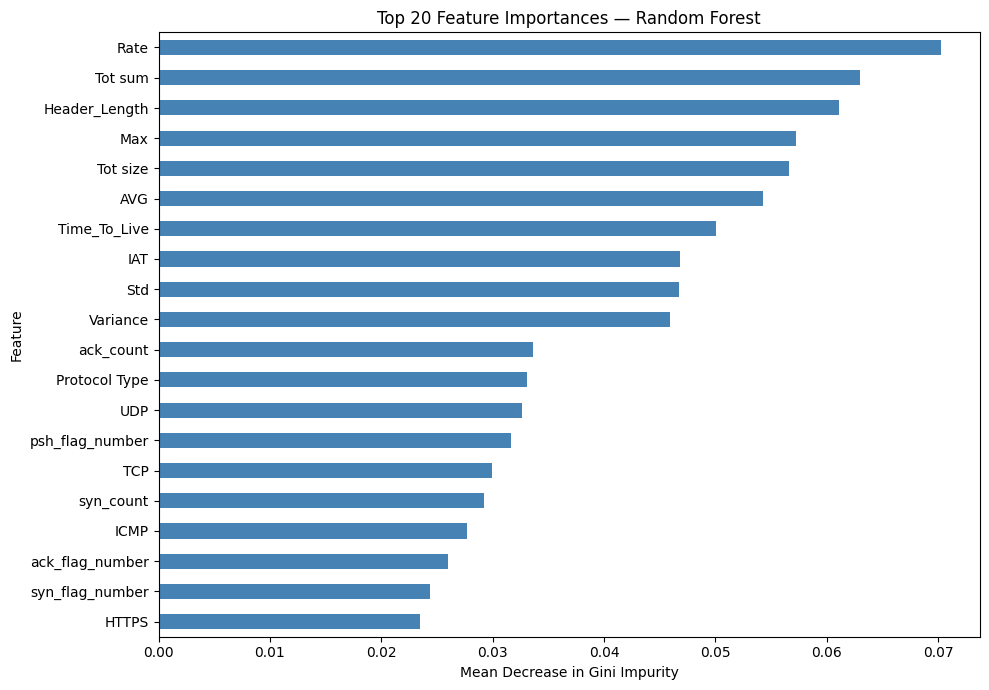


Top 20 features by importance:
Rate               0.070258
Tot sum            0.063014
Header_Length      0.061079
Max                0.057279
Tot size           0.056650
AVG                0.054284
Time_To_Live       0.050064
IAT                0.046799
Std                0.046762
Variance           0.045945
ack_count          0.033586
Protocol Type      0.033050
UDP                0.032681
psh_flag_number    0.031622
TCP                0.029940
syn_count          0.029186
ICMP               0.027726
ack_flag_number    0.025975
syn_flag_number    0.024390
HTTPS              0.023458


In [11]:
importances = pd.Series(final_rf.feature_importances_, index=feature_names)
top20 = importances.nlargest(20).sort_values()

plt.figure(figsize=(10, 7))
top20.plot(kind='barh', color='steelblue')
plt.xlabel('Mean Decrease in Gini Impurity')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

print('\nTop 20 features by importance:')
print(importances.nlargest(20).to_string())

## 12. Save Final Model

Save the fitted Random Forest with `joblib`. The filename records the preprocessing variant used.

The code below saves the final Random Forest model under `data/artifacts/RF/`.

In [12]:
save_dir  = Path('../data/artifacts/RF')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / f'random_forest_{FEATURE_VERSION}.joblib'
joblib.dump(final_rf, save_path)
print(f'Saved final model to: {save_path}')

Saved final model to: ..\data\artifacts\random_forest_scaled.joblib


## 13. Save Metrics

Save the run metrics to JSON. For Random Forest, raw and outlier-clipped variants are the most meaningful because scaling does not change tree splits.

The code below saves metrics and confusion matrix files for this variant.

In [13]:
import json

metrics_record = {
    'model':                'random_forest',
    'variant':              FEATURE_VERSION,
    'best_params':          {str(k): v for k, v in best_params_rf.items()},
    'n_iter':               int(final_rf.n_estimators),
    'n_classes':            int(N_CLASSES),
    'benign_label':         int(BENIGN_LABEL),
    'train_macro_f1':       float(train_metrics_rf['macro_f1']),
    'val_macro_f1':         float(val_metrics_rf['macro_f1']),
    'test_macro_f1':        float(final_test_metrics_rf['macro_f1']),
    'train_log_loss':       float(train_metrics_rf['log_loss']),
    'val_log_loss':         float(val_metrics_rf['log_loss']),
    'test_log_loss':        float(final_test_metrics_rf['log_loss']),
    'test_benign_fpr':      float(final_test_metrics_rf['benign_fpr']),
    'test_per_class_recall': final_test_metrics_rf['per_class_recall'].tolist(),
    'test_accuracy':        float(final_test_metrics_rf['accuracy']),
    'test_macro_precision': float(final_test_metrics_rf['macro_precision']),
    'test_macro_recall':    float(final_test_metrics_rf['macro_recall'])
}

metrics_path = save_dir / f'rf_metrics_{FEATURE_VERSION}.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics_record, f, indent=2)

cm_path = save_dir / f'rf_cm_{FEATURE_VERSION}.npy'
np.save(cm_path, final_test_metrics_rf['confusion_matrix'])

print(f'Saved metrics to:          {metrics_path}')
print(f'Saved confusion matrix to: {cm_path}')

Saved metrics to:          ..\data\artifacts\rf_metrics_scaled.json
Saved confusion matrix to: ..\data\artifacts\rf_cm_scaled.npy


## 14. Compare Variants

Load all saved Random Forest metrics and build a comparison table. Re-run this after each variant you train.

The code below gathers saved Random Forest metrics into one comparison CSV/table.

In [14]:
variant_files = sorted(save_dir.glob('rf_metrics_*.json'))

if not variant_files:
    print('No metrics files found yet. Re-run the notebook with a FEATURE_VERSION to populate this table.')
else:
    rows = []
    for f in variant_files:
        rec = json.loads(f.read_text())
        bp = rec['best_params']
        rows.append({
            'variant':         rec['variant'],
            'n_estimators':    bp.get('n_estimators'),
            'max_depth':       bp.get('max_depth'),
            'max_features':    bp.get('max_features'),
            'train_f1':        rec['train_macro_f1'],
            'val_f1':          rec['val_macro_f1'],
            'test_f1':         rec['test_macro_f1'],
            'train_val_gap':   rec['train_macro_f1'] - rec['val_macro_f1'],
            'test_benign_fpr': rec['test_benign_fpr'],
            'test_log_loss':   rec['test_log_loss'],
            'test_accuracy': rec.get('test_accuracy'),
            'test_macro_precision': rec.get('test_macro_precision'),
            'test_macro_recall': rec.get('test_macro_recall')
        })

    comp = pd.DataFrame(rows).sort_values('test_f1', ascending=False).reset_index(drop=True)
    print(f'Comparing {len(comp)} variant(s) of Random Forest:\n')
    print(comp.to_string(index=False))

    comp_path = save_dir / 'rf_comparison.csv'
    comp.to_csv(comp_path, index=False)
    print(f'\nSaved comparison table to: {comp_path}')

Comparing 4 variant(s) of Random Forest:

   variant  n_estimators  max_depth max_features  train_f1   val_f1  test_f1  train_val_gap  test_benign_fpr  test_log_loss  test_accuracy  test_macro_precision  test_macro_recall
    scaled           200         40         sqrt  0.956728 0.642292 0.643675       0.314436         0.292933       0.643705       0.754939              0.685036           0.635593
out_scaled           200         40         sqrt  0.980117 0.638878 0.643272       0.341239         0.307467       0.675983       0.750525              0.682616           0.633847
       raw           200         40         sqrt  0.975110 0.640862 0.642490       0.334248         0.293600       0.666877       0.751741              0.683166           0.633497
       out           200         40         log2  0.972569 0.639029 0.641453       0.333541         0.306000       0.670459       0.750391              0.680236           0.632766

Saved comparison table to: ..\data\artifacts\rf_compariso